# Bank Churn — Model 1/3: Logistic Regression

**Series plan:** `02_logistic_regression` (this notebook) → `03_xgboost` → `04_lightgbm`.
Each model gets the identical full treatment so results are directly comparable:

1. Leakage-free preprocessing pipeline (+ SMOTE inside the CV loop)
2. Imbalance-strategy comparison: no correction vs `class_weight` vs SMOTE
3. Hyperparameter tuning: **broad RandomizedSearchCV → refined GridSearchCV** around the found optimum
4. Full held-out evaluation: ROC curve, PR curve, confusion matrices, classification report, threshold analysis
5. Interpretability: coefficients (odds ratios) + SHAP

Logistic regression is the yardstick: every gradient-boosting point of AUC later must be
earned *against this*, not against a strawman.

## 1. Setup & data

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
assert df.shape == (10_000, 14) and df.isnull().sum().sum() == 0
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
print(f"Rows: {len(df)}, churn rate: {df['Exited'].mean():.2%}")

Found cached file: data/Churn_Modelling.csv
Rows: 10000, churn rate: 20.37%


## 2. Preprocessing pipeline

Same domain features as the EDA notebook. Key design choice for the *linear* model:
`NumOfProducts` enters as a **categorical** (`products_cat`) because its risk profile is
U-shaped — a single linear coefficient cannot represent "2 is safest, 3–4 is fatal".

SMOTE sits **inside** an `imblearn` pipeline, after encoding/scaling and before the
classifier. Two reasons: (i) SMOTE interpolates with k-NN, so features must be on a
common scale; (ii) inside the pipeline it is applied only to training folds during CV —
oversampling before the split would leak synthetic copies of validation points into
training and inflate every metric.

In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class DomainFeatures(BaseEstimator, TransformerMixin):
    """Adds EDA-motivated features; keeps the DataFrame interface."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["zero_balance"] = (X["Balance"] == 0).astype(int)
        X["balance_salary_ratio"] = X["Balance"] / (X["EstimatedSalary"] + 1.0)
        X["german_balance"] = (X["Geography"] == "Germany") * X["Balance"] / 1e5
        X["products_cat"] = X["NumOfProducts"].astype(str)
        X["inactive_senior"] = ((X["IsActiveMember"] == 0) & (X["Age"] >= 45)).astype(int)
        return X


CATEGORICAL = ["Geography", "Gender", "products_cat"]
NUMERIC = [
    "CreditScore", "Age", "Tenure", "Balance", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "zero_balance", "balance_salary_ratio",
    "german_balance", "inactive_senior",
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

X = df.drop(columns=["Exited"])
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape[0]} (churn {y_train.mean():.2%}) | "
      f"Test: {X_test.shape[0]} (churn {y_test.mean():.2%})")

Train: 8000 (churn 20.38%) | Test: 2000 (churn 20.35%)


One honest technical note on SMOTE here: after one-hot encoding, SMOTE's k-NN
interpolation produces fractional values on dummy columns (a synthetic customer can be
"0.4 German"). The design-correct alternative is `SMOTENC` on the raw mixed dataframe;
we use standard SMOTE on the encoded space (common practice, and the linear model reads
fractional dummies as soft category membership) and note SMOTENC as a variant to test.

## 3. Imbalance strategy comparison

Before tuning anything: does imbalance correction help at all, and which kind?
Three candidates, identical model, stratified 5-fold CV on the **training set only**.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "f1": "f1", "recall": "recall", "brier": "neg_brier_score"}

base_lr = dict(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)

strategies = {
    "No correction": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", LogisticRegression(**base_lr)),
    ]),
    "class_weight=balanced": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", **base_lr)),
    ]),
    "SMOTE": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(**base_lr)),
    ]),
}

rows = []
for name, pipe in strategies.items():
    # n_jobs=1: avoids noisy loky teardown on macOS + Python 3.13; data is small anyway.
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "strategy": name,
        **{m: f"{res[f'test_{m}'].mean():.4f}" for m in ["roc_auc", "pr_auc", "f1", "recall"]},
        "brier": f"{-res['test_brier'].mean():.4f}",
    })
print(pd.DataFrame(rows).set_index("strategy").to_string())

                      roc_auc  pr_auc      f1  recall   brier
strategy                                                     
No correction          0.8385  0.6521  0.5303  0.4153  0.1110
class_weight=balanced  0.8384  0.6496  0.5668  0.7221  0.1574
SMOTE                  0.8376  0.6493  0.5704  0.7325  0.1565


Expected pattern: all three tie on ROC-AUC / PR-AUC (rebalancing shifts the intercept,
not the ranking of a linear model), while `class_weight` and SMOTE trade Brier
(probability quality) for recall at the default 0.5 threshold. We proceed with the
**SMOTE pipeline** as the tuning target per the series design, and tune its sampling
parameters jointly with the regularization.

## 4. Hyperparameter search — stage 1: broad RandomizedSearchCV

Search space:
- `clf__C`: log-uniform over $[10^{-4}, 10^{3}]$ — regularization strength
- `clf__penalty`: L1 vs L2
- `smote__k_neighbors`: {3, 5, 7, 9, 11}
- `smote__sampling_strategy`: {0.4, 0.6, 0.8, 1.0} (minority:majority ratio after resampling)

40 samples × 5 folds = 200 fits. Objective: ROC-AUC (threshold-independent).

In [4]:
from scipy.stats import loguniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

smote_pipe = strategies["SMOTE"]

param_dist = {
    "clf__C": loguniform(1e-4, 1e3),
    "clf__penalty": ["l1", "l2"],
    "smote__k_neighbors": [3, 5, 7, 9, 11],
    "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    smote_pipe, param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0,
)
random_search.fit(X_train, y_train)

rs_best = random_search.best_params_
print(f"Best CV ROC-AUC (random stage): {random_search.best_score_:.4f}")
print("Best params:", rs_best)

rs_df = pd.DataFrame(random_search.cv_results_)
top5 = rs_df.nlargest(5, "mean_test_score")[
    ["mean_test_score", "std_test_score", "param_clf__C", "param_clf__penalty",
     "param_smote__k_neighbors", "param_smote__sampling_strategy"]
]
print("\nTop-5 configurations:")
print(top5.to_string(index=False))

Best CV ROC-AUC (random stage): 0.8388
Best params: {'clf__C': np.float64(0.47129737561107793), 'clf__penalty': 'l2', 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.4}

Top-5 configurations:
 mean_test_score  std_test_score  param_clf__C param_clf__penalty  param_smote__k_neighbors  param_smote__sampling_strategy
        0.838774        0.012275      0.471297                 l2                         3                             0.4
        0.838580        0.012608      0.599577                 l2                         5                             0.4
        0.838569        0.012613      1.744696                 l2                         5                             0.4
        0.838487        0.012612      0.397778                 l2                         3                             0.8
        0.838481        0.012331      0.877036                 l2                         3                             0.6


## 5. Hyperparameter search — stage 2: GridSearchCV around the optimum

The grid is built **programmatically around the stage-1 winner**: C on a narrow log-grid
(±0.5 decades), SMOTE parameters at the winner and its immediate neighbors, penalty fixed.

In [5]:
C_best = rs_best["clf__C"]
k_best = rs_best["smote__k_neighbors"]
s_best = rs_best["smote__sampling_strategy"]

param_grid = {
    "clf__C": np.round(np.logspace(np.log10(C_best) - 0.5, np.log10(C_best) + 0.5, 5), 6),
    "clf__penalty": [rs_best["clf__penalty"]],
    "smote__k_neighbors": sorted({max(2, k_best - 2), k_best, k_best + 2}),
    "smote__sampling_strategy": sorted({max(0.3, round(s_best - 0.2, 1)), s_best,
                                        min(1.0, round(s_best + 0.2, 1))}),
}
print("Refinement grid:", {k: list(v) for k, v in param_grid.items()})

grid_search = GridSearchCV(
    smote_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=1, refit=True,
)
grid_search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC (grid stage): {grid_search.best_score_:.4f} "
      f"(random stage was {random_search.best_score_:.4f})")
print("Final params:", grid_search.best_params_)
final_model = grid_search.best_estimator_

Refinement grid: {'clf__C': [np.float64(0.149037), np.float64(0.26503), np.float64(0.471297), np.float64(0.838098), np.float64(1.490373)], 'clf__penalty': ['l2'], 'smote__k_neighbors': [2, 3, 5], 'smote__sampling_strategy': [0.3, 0.4, 0.6]}

Best CV ROC-AUC (grid stage): 0.8388 (random stage was 0.8388)
Final params: {'clf__C': np.float64(1.490373), 'clf__penalty': 'l2', 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.4}


## 6. Held-out evaluation — the full picture

Everything below uses the untouched 20% test set.

### 6.1 ROC and Precision-Recall curves

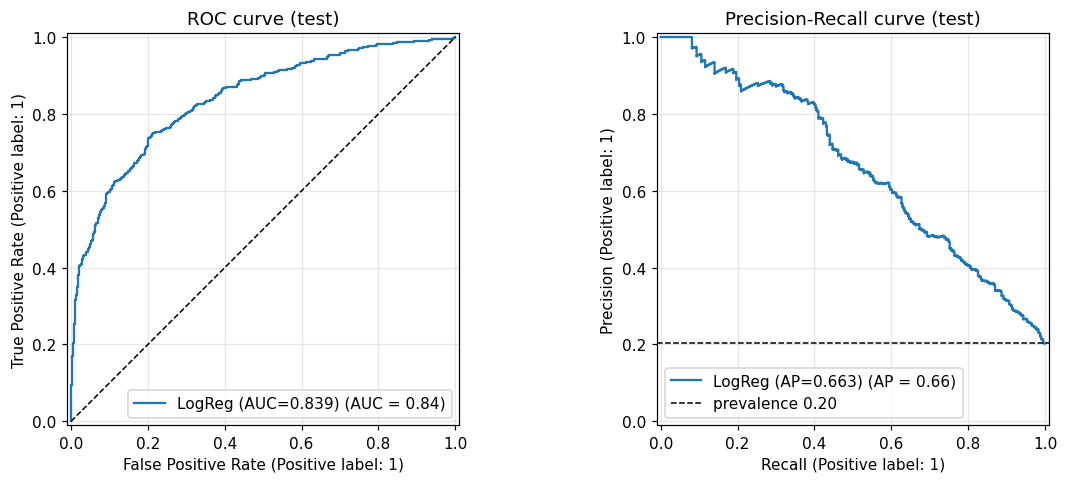

Test ROC-AUC: 0.8389 | Test PR-AUC (AP): 0.6625


In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score,
)

p_test = final_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0],
                                 name=f"LogReg (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (test)")

PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1],
                                        name=f"LogReg (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"prevalence {y_test.mean():.2f}")
axes[1].legend()
axes[1].set_title("Precision-Recall curve (test)")
plt.tight_layout()
plt.show()
print(f"Test ROC-AUC: {auc:.4f} | Test PR-AUC (AP): {ap:.4f}")

The PR curve is the honest one under 20% prevalence: the dashed line is the precision a
random ranker achieves, so the gap above it — not the distance to 1.0 — is the model's
actual contribution.

### 6.2 Confusion matrices: default vs F1-optimal threshold

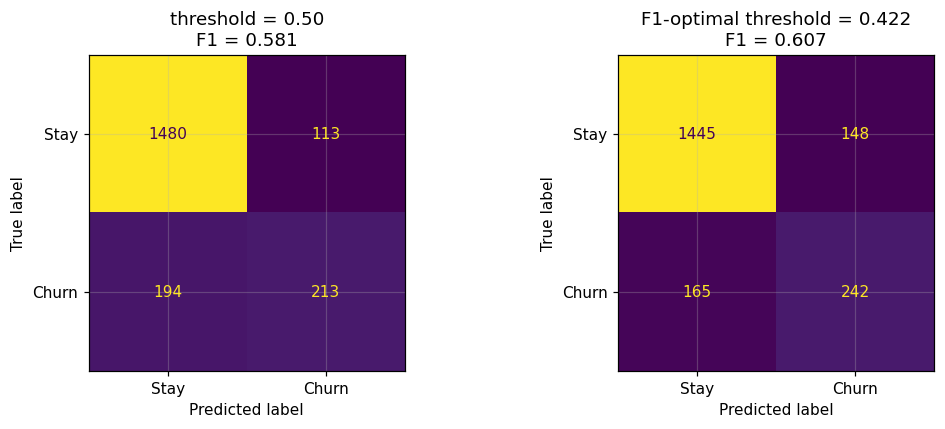

Classification report @ F1-optimal threshold:

              precision    recall  f1-score   support

        Stay       0.90      0.91      0.90      1593
       Churn       0.62      0.59      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [7]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
t_f1 = thr[f1_scores.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, label in [(axes[0], 0.5, "threshold = 0.50"),
                     (axes[1], t_f1, f"F1-optimal threshold = {t_f1:.3f}")]:
    cm = confusion_matrix(y_test, p_test >= t)
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Churn"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{label}\nF1 = {f1_score(y_test, p_test >= t):.3f}")
plt.tight_layout()
plt.show()

print("Classification report @ F1-optimal threshold:\n")
print(classification_report(y_test, p_test >= t_f1, target_names=["Stay", "Churn"]))

Note that SMOTE shifts the probability distribution upward (the model is trained on a
rebalanced world), so the F1-optimal threshold lands well above where it would for an
uncorrected model — thresholds and resampling choices are not independent decisions.

### 6.3 Score distribution by class

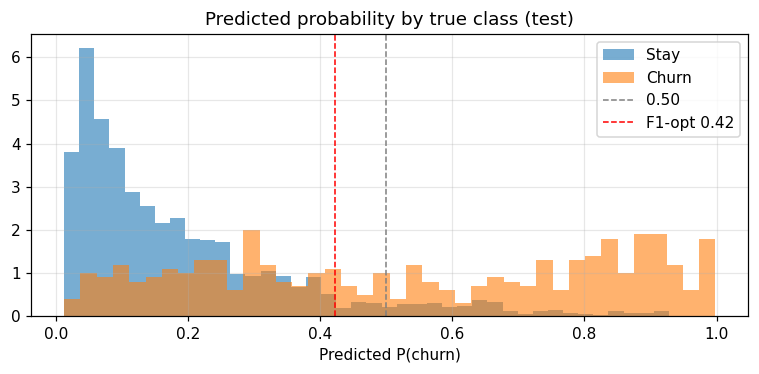

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, name in [(0, "Stay"), (1, "Churn")]:
    ax.hist(p_test[y_test == label], bins=40, alpha=0.6, density=True, label=name)
ax.axvline(0.5, ls="--", c="gray", lw=1, label="0.50")
ax.axvline(t_f1, ls="--", c="red", lw=1, label=f"F1-opt {t_f1:.2f}")
ax.set_xlabel("Predicted P(churn)")
ax.set_title("Predicted probability by true class (test)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Interpretability

### 7.1 Coefficients as odds ratios

For a linear model this is the native language: `exp(beta)` is the multiplicative change
in churn odds per one standard deviation (numeric) or vs the reference category (dummies).

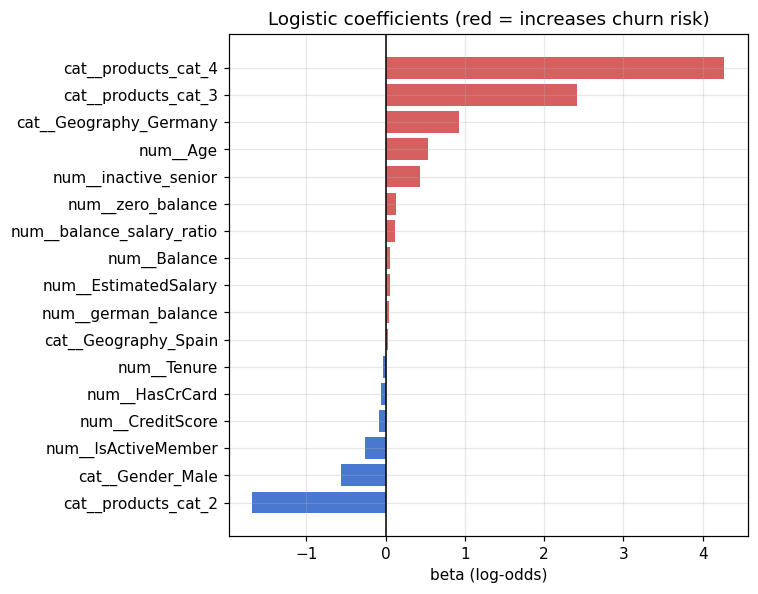

                  feature   beta  odds_ratio
      cat__products_cat_2 -1.679       0.187
         cat__Gender_Male -0.561       0.571
      num__IsActiveMember -0.265       0.767
         num__CreditScore -0.081       0.922
           num__HasCrCard -0.059       0.943
              num__Tenure -0.029       0.971
     cat__Geography_Spain  0.026       1.026
      num__german_balance  0.041       1.042
     num__EstimatedSalary  0.056       1.058
             num__Balance  0.060       1.061
num__balance_salary_ratio  0.114       1.120
        num__zero_balance  0.137       1.147
     num__inactive_senior  0.434       1.543
                 num__Age  0.530       1.699
   cat__Geography_Germany  0.924       2.520
      cat__products_cat_3  2.413      11.162
      cat__products_cat_4  4.274      71.825


In [9]:
feat_names = final_model.named_steps["prep"].get_feature_names_out()
coefs = final_model.named_steps["clf"].coef_[0]
coef_df = (pd.DataFrame({"feature": feat_names, "beta": coefs})
           .assign(odds_ratio=lambda d: np.exp(d["beta"]))
           .sort_values("beta"))

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["#D65F5F" if b > 0 else "#4878CF" for b in coef_df["beta"]]
ax.barh(coef_df["feature"], coef_df["beta"], color=colors)
ax.axvline(0, c="k", lw=1)
ax.set_title("Logistic coefficients (red = increases churn risk)")
ax.set_xlabel("beta (log-odds)")
plt.tight_layout()
plt.show()
print(coef_df.round(3).to_string(index=False))

### 7.2 SHAP

For a linear model SHAP adds little beyond coefficients on *global* structure, but the
beeswarm shows how feature *distributions* interact with those coefficients, and it makes
this notebook directly comparable with the XGBoost/LightGBM SHAP plots later.

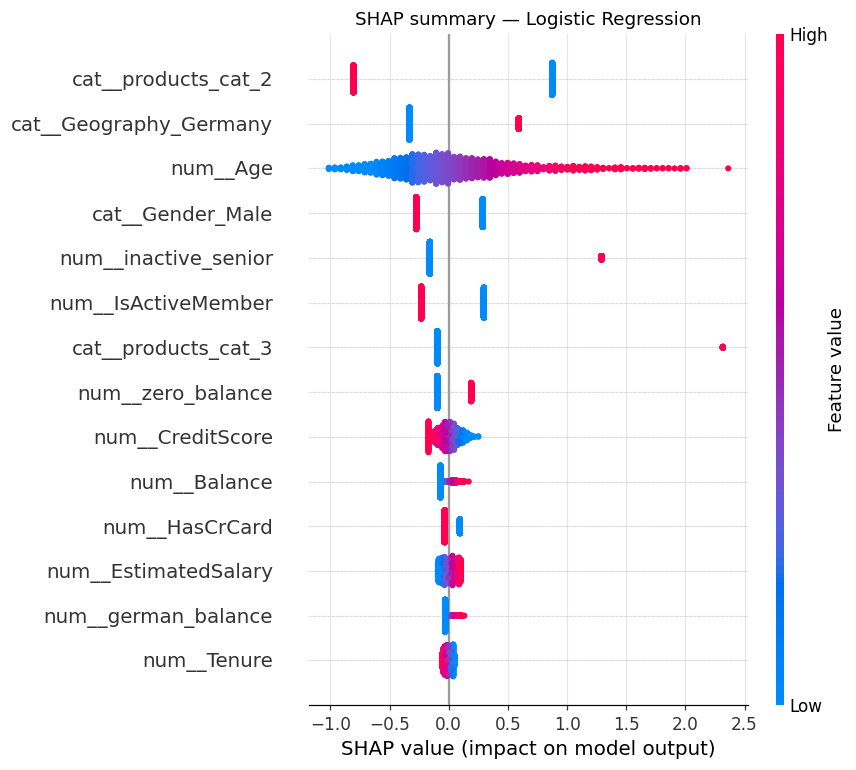

In [10]:
import shap

# A sliced imblearn pipeline containing the SMOTE step exposes no .transform
# (samplers only act at fit time), so apply the transformer steps explicitly.
_domain = final_model.named_steps["domain"]
_prep = final_model.named_steps["prep"]
X_train_tr = pd.DataFrame(_prep.transform(_domain.transform(X_train)), columns=feat_names)
X_test_tr = pd.DataFrame(_prep.transform(_domain.transform(X_test)), columns=feat_names)

explainer = shap.LinearExplainer(final_model.named_steps["clf"], X_train_tr)
shap_values = explainer.shap_values(X_test_tr)

shap.summary_plot(shap_values, X_test_tr, max_display=14, show=False)
plt.title("SHAP summary — Logistic Regression")
plt.tight_layout()
plt.show()

## 8. Results summary & next step

| Item | Value |
|---|---|
| Tuning | RandomizedSearchCV (40 cand.) → GridSearchCV refinement |
| CV ROC-AUC (train) | see grid output above |
| Test ROC-AUC / PR-AUC | printed in §6.1 |
| Imbalance handling | SMOTE inside the CV pipeline; strategy comparison in §3 |

The linear model's ceiling is structural, not a tuning artifact: the two strongest
drivers found in EDA (age, product count) are non-linear/U-shaped, and one-hot
`products_cat` only partially repairs that. This is precisely the headroom the
tree-based models should convert in the next notebooks.

**Next:** `03_xgboost.ipynb` — identical evaluation protocol, same two-stage search.